In [ ]:
!pip install -r requirements.txt
!pip install fastexcel

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from scipy.stats import randint
import shap

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

# Data Inspection

In [12]:
# Polars loads the Excel file much faster on my machine than pandas.
df_odin = pl.read_excel('Data/OdiN/ODiN2024 Updated with Header/ODiN2024_DANS_Databestand_ Updated.xlsx').to_pandas()
df_odin.head()

,OP,OPID,Mode,HHPers_DANS24,HHSam_DANS24,HHLft1_DANS24,HHLft2_DANS24,HHLft3_DANS24,HHLft4_DANS24,Wogem_DANS24,Sted,GemGr,Prov,Corop,Geslacht,KLeeft,BetWerk,OnbBez_DANS24,MaatsPart_DANS24,Opleiding_DANS24,HHGestInkG,HHRijbewijsAu,HHRijbewijsMo,HHRijbewijsBr,OPRijbewijsAu,OPRijbewijsMo,OPRijbewijsBr,HHAuto_DANS24,HHAutoL_DANS24,OPAuto_DANS24,BrandstofPa1_DANS24,KBouwjaarPa1_DANS24,KGewichtPa1_DANS24,BrandstofPa2_DANS24,KBouwjaarPa2_DANS24,KGewichtPa2_DANS24,BrandstofPaL_DANS24,KBouwjaarPaL_DANS24,KGewichtPaL_DANS24,HHMotor_DANS24,HHBrSn_DANS24,HHEFiets_DANS24,HHBezitVm_DANS24,OPBezitVm_DANS24,FqLopen,FqNEFiets,FqEFiets,FqBTM,FqTrein,FqAutoB,FqAutoP,FqMotor,FqBrSnor,OVStKaart,WrkVervw,WrkVerg,VergVast,VergKm,VergBrSt,VergOV,...,VertGem_DANS24,VertProv,VertCorop,AankGeb,AankPC_PRAM,AankGem_DANS24,AankProv,AankCorop,GemG_DANS24,AfstV,KAfstV,Hvm,HvmRol,KHvm,VertUur,VertMin,KVertTijd,AankUur,AankMin,Reisduur,KReisduur,ActDuur,Kind6,VolgWerk,SAantAdr,SDezPlts,AfstS,AfstSBL,SVvm1,SVvm2,SVvm3,SVvm4,SBegUur,SBegMin,SEindUur,SEindMin,CorrVerpl,GehBLVer,Rit,RitID,RitNr,AfstR,AfstRBL,KAfstR,Rvm,RvmRol,RAantIn,KRvm,RVertUur,RVertMin,RAankUur,RAankMin,RReisduur,RReisduurBL,RTSamen,RCorrSnelh,RVliegVer,FactorH,FactorP,FactorV
0,1,350000661958,1,2,2,0,0,0,2,995,3,5,5,40,1,16,0,1,5,3,6,2,2,2,1,1,1,1,0,1,4,2,2,6,5,4,6,3,4,0,0,0,2,1,1,1,5,5,5,2,3,5,5,4,12,3,2,2,2,2,...,995.0,5.0,40.0,0.0,6721,228.0,6.0,13.0,0.0,1300.0,15.0,1.0,1.0,1.0,13.0,0.0,7.0,15.0,0.0,120.0,11.0,60.0,0.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,3.500007e+15,1.0,1300.0,0.0,15.0,1.0,1.0,2.0,1.0,13.0,0.0,15.0,0.0,120.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
1,0,350000661958,1,2,2,0,0,0,2,995,3,5,5,40,1,16,0,1,5,3,6,2,2,2,1,1,1,1,0,1,4,2,2,6,5,4,6,3,4,0,0,0,2,1,1,1,5,5,5,2,3,5,5,4,12,3,2,2,2,2,...,228.0,6.0,13.0,0.0,6846,202.0,6.0,15.0,0.0,700.0,13.0,1.0,1.0,1.0,16.0,0.0,9.0,17.0,0.0,60.0,9.0,195.0,0.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,3.500007e+15,1.0,700.0,0.0,13.0,1.0,1.0,2.0,1.0,16.0,0.0,17.0,0.0,60.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
2,0,350000661958,1,2,2,0,0,0,2,995,3,5,5,40,1,16,0,1,5,3,6,2,2,2,1,1,1,1,0,1,4,2,2,6,5,4,6,3,4,0,0,0,2,1,1,1,5,5,5,2,3,5,5,4,12,3,2,2,2,2,...,202.0,6.0,15.0,0.0,8211,995.0,5.0,40.0,0.0,1200.0,15.0,1.0,1.0,1.0,20.0,15.0,13.0,22.0,0.0,105.0,10.0,NaN,0.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,3.500007e+15,1.0,1200.0,0.0,15.0,1.0,1.0,2.0,1.0,20.0,15.0,22.0,0.0,105.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
3,1,350000773958,1,2,2,0,0,0,2,1740,5,4,6,16,2,8,3,5,2,3,10,2,0,2,1,0,1,2,0,1,3,3,1,3,2,2,6,3,4,0,0,0,1,1,3,5,5,5,5,1,3,5,5,0,4,1,1,0,0,2,...,1740.0,6.0,16.0,0.0,3772,203.0,6.0,13.0,0.0,380.0,11.0,1.0,1.0,1.0,8.0,20.0,4.0,8.0,55.0,35.0,7.0,560.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,3.500008e+15,1.0,380.0,0.0,11.0,1.0,1.0,1.0,1.0,8.0,20.0,8.0,55.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908
4,0,350000773958,1,2,2,0,0,0,2,1740,5,4,6,16,2,8,3,5,2,3,10,2,0,2,1,0,1,2,0,1,3,3,1,3,2,2,6,3,4,0,0,0,1,1,3,5,5,5,5,1,3,5,5,0,4,1,1,0,0,2,...,203.0,6.0,13.0,0.0,6669,1740.0,6.0,16.0,0.0,380.0,11.0,1.0,1.0,1.0,18.0,15.0,11.0,18.0,50.0,35.0,7.0,NaN,0.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,3.500008e+15,1.0,380.0,0.0,11.0,1.0,1.0,1.0,1.0,18.0,15.0,18.0,50.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908


In [13]:
df_cbs = pd.read_csv('outputs/combined_neighbourhood_dataset.csv')
df_cbs = df_cbs.dropna(subset=['PC4']).copy()
df_cbs.describe()

/var/folders/0n/x8lc24n57r1ckx_w_t74z_3c0000gn/T/ipykernel_10117/1033024767.py:1: DtypeWarning: Columns (16,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cbs = pd.read_csv('outputs/combined_neighbourhood_dataset.csv')


,klasse_apotheek,klasse_basisschool,klasse_bushalte,klasse_fastfood,klasse_horeca,klasse_huisarts,klasse_kinderopvang,klasse_kledingwinkel,klasse_restaurant,klasse_sportterrein,klasse_supermarkt,klasse_treinstation,klasse_voortgezet_onderwijs,klasse_ziekenhuis,aantal_drinkwaterpunt,ind_wbi,a_inw,a_man,a_vrouw,a_00_14,a_15_24,a_25_44,a_45_64,a_65_oo,a_ongeh,a_gehuwd,a_gesch,a_verwed,a_nl_all,a_eur_al,a_neu_al,a_geb_nl,a_geb_eu,a_geb_ne,a_gbl_eu,a_gbl_ne,a_geb,p_geb,a_ste,p_ste,a_hh,a_1p_hh,a_hh_z_k,a_hh_m_k,g_hhgro,bev_dich,a_woning,a_nb_won,a_vastg,a_nb_vastg,g_wozbag,p_1gezw,p_1gezw_tw,p_1gezw_hw,p_1gezw_2w,p_1gezw_hvw,p_mgezw,p_leegsw,p_koopw,p_huurw,...,walk15_total_facilities,walk15_weighted_score,bike10_direct_klasse_apotheek,bike10_direct_klasse_basisschool,bike10_direct_klasse_bushalte,bike10_direct_klasse_fastfood,bike10_direct_klasse_horeca,bike10_direct_klasse_huisarts,bike10_direct_klasse_kinderopvang,bike10_direct_klasse_kledingwinkel,bike10_direct_klasse_restaurant,bike10_direct_klasse_sportterrein,bike10_direct_klasse_supermarkt,bike10_direct_klasse_treinstation,bike10_direct_klasse_voortgezet_onderwijs,bike10_direct_klasse_ziekenhuis,bike10_direct_score,bike10_direct_total_facilities,bike10_direct_weighted_score,ebike10_direct_klasse_apotheek,ebike10_direct_klasse_basisschool,ebike10_direct_klasse_bushalte,ebike10_direct_klasse_fastfood,ebike10_direct_klasse_horeca,ebike10_direct_klasse_huisarts,ebike10_direct_klasse_kinderopvang,ebike10_direct_klasse_kledingwinkel,ebike10_direct_klasse_restaurant,ebike10_direct_klasse_sportterrein,ebike10_direct_klasse_supermarkt,ebike10_direct_klasse_treinstation,ebike10_direct_klasse_voortgezet_onderwijs,ebike10_direct_klasse_ziekenhuis,ebike10_direct_score,ebike10_direct_total_facilities,ebike10_direct_weighted_score,walk15_direct_klasse_apotheek,walk15_direct_klasse_basisschool,walk15_direct_klasse_bushalte,walk15_direct_klasse_fastfood,walk15_direct_klasse_horeca,walk15_direct_klasse_huisarts,walk15_direct_klasse_kinderopvang,walk15_direct_klasse_kledingwinkel,walk15_direct_klasse_restaurant,walk15_direct_klasse_sportterrein,walk15_direct_klasse_supermarkt,walk15_direct_klasse_treinstation,walk15_direct_klasse_voortgezet_onderwijs,walk15_direct_klasse_ziekenhuis,walk15_direct_score,walk15_direct_total_facilities,walk15_direct_weighted_score,PC4,pct_within_10min,mean_dist_km,mean_time_min,n_trips_weighted,bike_detour_rate,ebike_detour_rate
count,14096.000000,14096.000000,14096.0,14096.000000,14096.000000,14096.000000,14096.0,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14093.000000,14090.000000,14093.000000,14084.000000,14093.000000,14093.000000,14093.000000,14093.000000,13788.000000,13459.000000,14093.000000,14093.000000,14093.000000,14093.000000,12435.000000,12564.000000,12564.000000,12564.000000,12564.000000,12564.000000,12564.000000,12564.000000,12563.000000,12563.000000,...,14096.000000,14096.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14048.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,14080.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,12512.000000,14096.000000,10832.000000,10832.000000,10832.000000,1.083200e+04,14096.000000,14096.000000
mean

In [14]:
missing = df_odin.isnull().sum()
missing_pct = (missing / len(df_odin) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing count': missing,
    'Missing %': missing_pct,
    'Non-missing': df_odin.notnull().sum(),
    'Dtype': df_odin.dtypes
}).sort_values('Missing %', ascending=False)

missing_summary.head(20)

,Missing count,Missing %,Non-missing,Dtype
SEindUur,212514,99.57,909,float64
SAantAdr,212514,99.57,909,float64
SBegMin,212514,99.57,909,float64
SBegUur,212514,99.57,909,float64
SVvm4,212514,99.57,909,float64
SVvm3,212514,99.57,909,float64
SVvm2,212514,99.57,909,float64
SVvm1,212514,99.57,909,float64
AfstSBL,212514,99.57,909,float64
AfstS,212514,99.57,909,float64


# Data Preprocessing

In [15]:
def clean_pc4(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.endswith('.0'):
        text = text[:-2]
    text = ''.join(ch for ch in text if ch.isdigit())
    return text.zfill(4) if text else np.nan

In [16]:
# Target is KHvm, so we do not select columns that directly reveal the chosen mode.

selected_odin_columns = [
    'KHvm', 'OPID',
    'AfstV', 'KVertTijd', 'Weekdag', 'Maand', 'VertLoc', 'Doel',
    'KLeeft', 'Geslacht', 'Opleiding_DANS24', 'BetWerk', 'OPRijbewijsAu',
    'HHGestInkG', 'HHPers_DANS24', 'HHSam_DANS24',
    'HHAuto_DANS24', 'HHRijbewijsAu', 'OPAuto_DANS24',
    'HHBrSn_DANS24', 'HHEFiets_DANS24', 'OVStKaart',
    'Sted', 'Prov', 'GemGr', 'Corop',
    'FqLopen', 'FqNEFiets', 'FqEFiets', 'FqBTM', 'FqTrein',
    'FqAutoB', 'FqAutoP', 'FqBrSnor',
    'WrkVerg', 'VergOV',
    'BrbWrk', 'BrbOnd', 'BrbSport', 'BrbSup', 'BrbZiek', 'BrbArts',
    'BrbStat', 'BrbHalte', 'VertPC_PRAM', 'Verpl'
]

df = df_odin[selected_odin_columns].copy()

# Keep only actual trips and the KHvm classes relevant for our 4-class mode choice task.
df['KHvm'] = pd.to_numeric(df['KHvm'], errors='coerce')
df['Verpl'] = pd.to_numeric(df['Verpl'], errors='coerce')
df = df[df['Verpl'] == 1].copy()
df = df[df['KHvm'].isin([1, 2, 3, 4, 5, 6])].copy()

print(df.shape)
df[['KHvm', 'Verpl', 'VertPC_PRAM']].head()

(172465, 46)


,KHvm,Verpl,VertPC_PRAM
0,1.0,1.0,8211
1,1.0,1.0,6721
2,1.0,1.0,6846
3,1.0,1.0,6669
4,1.0,1.0,3772


In [17]:
feature_labels = {
    "AfstV": "Trip Distance",
    "KVertTijd": "Departure Time Class",
    "Weekdag": "Day of Week",
    "Maand": "Month",
    "VertLoc": "Origin Location Type",
    "Corop": "COROP Region",
    "Doel": "Trip Purpose",

    "KLeeft": "Age Group",
    "Geslacht": "Gender",
    "Opleiding_DANS24": "Education Level",
    "BetWerk": "Paid Employment",
    "OPRijbewijsAu": "Has Car Driving Licence",
    "OPAuto_DANS24": "Car Registered To Respondent",

    "HHGestInkG": "Household Income Decile",
    "HHPers_DANS24": "Household Size",
    "HHSam_DANS24": "Household Composition",
    "HHAuto_DANS24": "Household Car Availability",
    "HHRijbewijsAu": "Household Car Driving Licences",
    "HHEFiets_DANS24": "Household E-Bike Availability",
    "OVStKaart": "Student Public Transport Card",

    "FqLopen": "Walking Frequency",
    "FqNEFiets": "Bicycle Use Frequency",
    "FqEFiets": "E-Bike Use Frequency",
    "FqBTM": "Bus/Tram/Metro Use Frequency",
    "FqTrein": "Train Use Frequency",
    "FqAutoB": "Car Driver Frequency",
    "FqAutoP": "Car Passenger Frequency",
    "FqBrSnor": "Moped Use Frequency",

    "WrkVerg": "Employer Travel Reimbursement",
    "VergOV": "Public Transport Reimbursement",
    "VergVast": "Fixed Travel Reimbursement",
    "VergKm": "Kilometre-Based Travel Reimbursement",

    "BrbWrk": "Perceived Work Access",
    "BrbOnd": "Perceived Education Access",
    "BrbSup": "Perceived Supermarket Access",
    "BrbZiek": "Perceived Hospital Access",
    "BrbArts": "Perceived GP Access",
    "BrbStat": "Perceived Train Station Access",
    "BrbHalte": "Perceived Bus/Tram/Metro Stop Access",
    "BrbSport": "Perceived Sports Facility Access",

    "klasse_supermarkt": "Supermarket Availability",
    "klasse_huisarts": "GP Availability",
    "klasse_basisschool": "Primary School Availability",
    "klasse_ziekenhuis": "Hospital Availability",
    "klasse_apotheek": "Pharmacy Availability",
    "klasse_treinstation": "Train Station Availability",
    "klasse_voortgezet_onderwijs": "Secondary School Availability",
    "klasse_sportterrein": "Sports Facility Availability",
}

In [18]:
# Link the Topic 1 combined dataset to ODiN by PC4.
# The klasse_* variables are 0/1 at neighborhood level.
# After grouping by PC4 they become proportions: share of neighborhoods in that PC4 with the amenity.

df_cbs['pc4'] = df_cbs['PC4'].apply(clean_pc4)
df['pc4'] = df['VertPC_PRAM'].apply(clean_pc4)

amenity_features = [
    'klasse_supermarkt',
    'klasse_huisarts',
    'klasse_basisschool',
    'klasse_ziekenhuis',
    'klasse_apotheek',
    'klasse_bushalte',
    'klasse_treinstation',
    'klasse_voortgezet_onderwijs',
    'klasse_kinderopvang',
    'klasse_sportterrein',
]

for col in amenity_features:
    df_cbs[col] = pd.to_numeric(df_cbs[col], errors='coerce')

pc4_access_features = (
    df_cbs
    .dropna(subset=['pc4'])
    .groupby('pc4', as_index=False)[amenity_features]
    .mean()
)

# These two are constant in the current combined dataset after PC4 aggregation.
constant_amenity_features = [c for c in amenity_features if pc4_access_features[c].nunique(dropna=True) <= 1]
model_amenity_features = [c for c in amenity_features if c not in constant_amenity_features]

print('Dropped constant amenity features:', constant_amenity_features)
print('Amenity features used:', model_amenity_features)
pc4_access_features.head()

Dropped constant amenity features: ['klasse_bushalte', 'klasse_kinderopvang']
Amenity features used: ['klasse_supermarkt', 'klasse_huisarts', 'klasse_basisschool', 'klasse_ziekenhuis', 'klasse_apotheek', 'klasse_treinstation', 'klasse_voortgezet_onderwijs', 'klasse_sportterrein']


,pc4,klasse_supermarkt,klasse_huisarts,klasse_basisschool,klasse_ziekenhuis,klasse_apotheek,klasse_bushalte,klasse_treinstation,klasse_voortgezet_onderwijs,klasse_kinderopvang,klasse_sportterrein
0,1011,0.666667,0.444444,0.222222,0.000000,0.222222,1.0,0.000000,0.000000,1.0,0.0
1,1012,1.000000,0.307692,0.000000,0.076923,0.153846,1.0,0.076923,0.000000,1.0,0.0
2,1013,0.263158,0.315789,0.105263,0.000000,0.105263,1.0,0.000000,0.105263,1.0,0.0
3,1014,0.000000,0.200000,0.200000,0.100000,0.100000,1.0,0.000000,0.300000,1.0,0.2
4,1015,0.625000,0.625000,0.250000,0.000000,0.500000,1.0,0.000000,0.125000,1.0,0.0


In [19]:
df = df.merge(pc4_access_features[['pc4'] + model_amenity_features], on='pc4', how='left')

# KHvm is recoded to 4 classes: car, public transport, bike, walking.
df['target'] = df['KHvm'].astype(int).replace({
    1: 0,   # Car-driver -> Car
    2: 0,   # Car-passenger -> Car
    3: 1,   # Train -> Public transport
    4: 1,   # Bus/tram/metro -> Public transport
    5: 2,   # Bike
    6: 3,   # Walking
})

class_labels = {
    0: 'Car',
    1: 'Public Transport',
    2: 'Bike',
    3: 'Walking',
}
label_names = [class_labels[i] for i in sorted(class_labels)]

groups = df['OPID']
y = df['target'].astype(int)

X_full = df.drop(columns=['KHvm', 'target', 'OPID', 'VertPC_PRAM', 'Verpl', 'pc4']).copy()

# Tree-based models can handle unscaled numeric input. ODiN categorical codes are kept as numeric coded controls.
for col in X_full.columns:
    X_full[col] = pd.to_numeric(X_full[col], errors='coerce')

print('Rows:', len(X_full))
print('Features:', X_full.shape[1])
print('Rows without PC4 amenity match:', X_full[model_amenity_features].isna().all(axis=1).mean().round(4))
X_full.head()

Rows: 172465
Features: 50
Rows without PC4 amenity match: 0.0444


,AfstV,KVertTijd,Weekdag,Maand,VertLoc,Doel,KLeeft,Geslacht,Opleiding_DANS24,BetWerk,OPRijbewijsAu,HHGestInkG,HHPers_DANS24,HHSam_DANS24,HHAuto_DANS24,HHRijbewijsAu,OPAuto_DANS24,HHBrSn_DANS24,HHEFiets_DANS24,OVStKaart,Sted,Prov,GemGr,Corop,FqLopen,FqNEFiets,FqEFiets,FqBTM,FqTrein,FqAutoB,FqAutoP,FqBrSnor,WrkVerg,VergOV,BrbWrk,BrbOnd,BrbSport,BrbSup,BrbZiek,BrbArts,BrbStat,BrbHalte,klasse_supermarkt,klasse_huisarts,klasse_basisschool,klasse_ziekenhuis,klasse_apotheek,klasse_treinstation,klasse_voortgezet_onderwijs,klasse_sportterrein
0,1300.0,7.0,6,8,1.0,9.0,16,1,3,0,1,6,2,2,1,2,1,0,0,4,3,5,5,40,1,1,5,5,5,2,3,5,3,2,4,4,1,1,1,1,1,5,0.000000,0.000000,0.000000,0.0,0.000000,0.000,0.000000,0.000000
1,700.0,9.0,6,8,4.0,9.0,16,1,3,0,1,6,2,2,1,2,1,0,0,4,3,5,5,40,1,1,5,5,5,2,3,5,3,2,4,4,1,1,1,1,1,5,0.333333,0.166667,0.666667,0.0,0.166667,0.000,0.000000,0.166667
2,1200.0,13.0,6,8,4.0,1.0,16,1,3,0,1,6,2,2,1,2,1,0,0,4,3,5,5,40,1,1,5,5,5,2,3,5,3,2,4,4,1,1,1,1,1,5,0.333333,0.333333,1.000000,0.0,0.333333,0.000,0.333333,0.333333
3,380.0,4.0,2,7,1.0,2.0,8,2,3,3,1,10,2,2,2,2,1,0,0,0,5,6,4,16,3,5,5,5,5,1,3,5,1,2,3,5,5,3,3,1,3,2,0.250000,0.250000,0.250000,0.0,0.000000,0.250,0.000000,0.250000
4,380.0,11.0,2,7,3.0,1.0,8,2,3,3,1,10,2,2,2,2,1,0,0,0,5,6,4,16,3,5,5,5,5,1,3,5,1,2,3,5,5,3,3,1,3,2,0.500000,0.250000,0.375000,0.0,0.250000,0.125,0.000000,0.000000


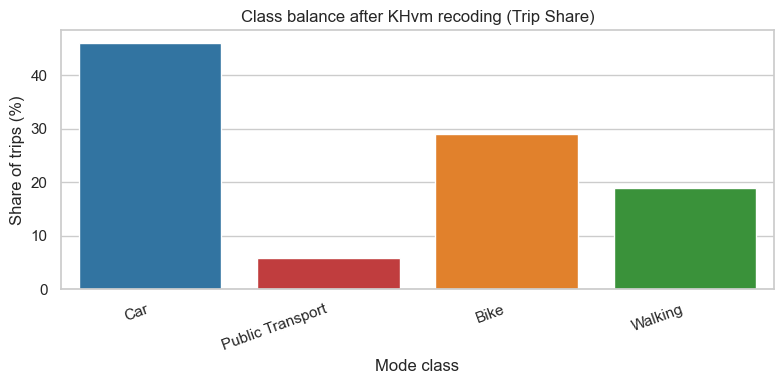

In [20]:
plt.figure(figsize=(8, 4))
shares = (df['target'].map(class_labels).value_counts(normalize=True) * 100).reset_index()
shares.columns = ['Mode class', 'Share (%)']
order = [class_labels[i] for i in sorted(class_labels)]

sns.barplot(
    data=shares,
    x='Mode class',
    y='Share (%)',
    order=order,
    hue='Mode class',
    palette='tab10',
    legend=False,
)

plt.title('Class balance after KHvm recoding (Trip Share)')
plt.xlabel('Mode class')
plt.ylabel('Share of trips (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("images/travelmode_share_afterrecoding.png", dpi= 150)
plt.show()

In [21]:
# Creating train and test splits. We split by OPID so trips from the same respondent
# does not appear in both the train and test set.
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test  = X_full.iloc[test_idx].copy()
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# Impute missing values using train-set medians only.
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print('Train:', X_train.shape)
print('Test:', X_test.shape)
print('Respondents train/test:', groups_train.nunique(), groups.iloc[test_idx].nunique())

Train: (146544, 50)
Test: (25921, 50)
Respondents train/test: 45972 8113


## RF Based Feature Selection

In [22]:
def make_pipe(model):
    return Pipeline([
        ('classifier', model)
    ])

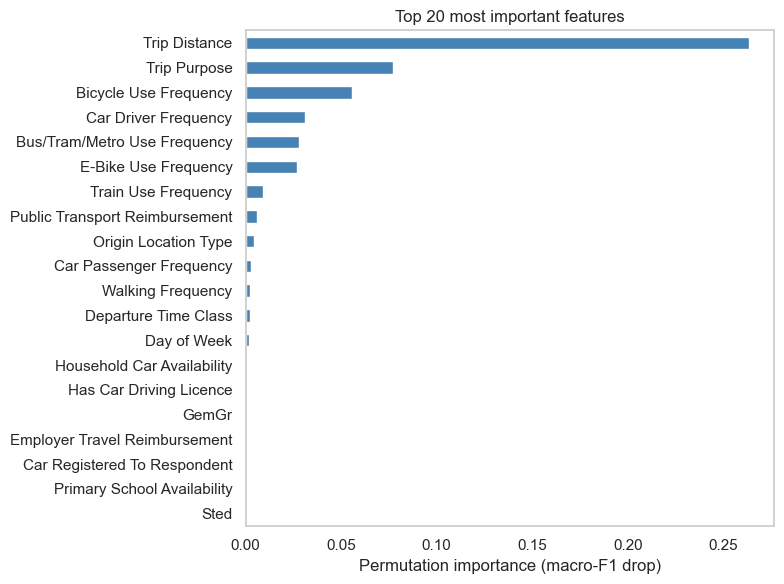

AfstV                          0.263388
Doel                           0.077402
FqNEFiets                      0.055871
FqAutoB                        0.031051
FqBTM                          0.028060
FqEFiets                       0.027122
FqTrein                        0.008861
VergOV                         0.006093
VertLoc                        0.004494
FqAutoP                        0.002948
FqLopen                        0.002509
KVertTijd                      0.002150
Weekdag                        0.002029
HHAuto_DANS24                  0.000902
OPRijbewijsAu                  0.000564
GemGr                          0.000454
WrkVerg                        0.000398
OPAuto_DANS24                  0.000396
klasse_basisschool             0.000266
Sted                           0.000234
FqBrSnor                       0.000112
HHRijbewijsAu                  0.000105
BetWerk                        0.000065
Corop                          0.000044
BrbSport                      -0.000001


In [23]:
# Use a validation split within the training set to compute permutation importance.
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
tr_idx, val_idx = next(gss_val.split(X_train, y_train, groups=groups_train))

X_tr = X_train.iloc[tr_idx]
X_val = X_train.iloc[val_idx]
y_tr = y_train.iloc[tr_idx]
y_val = y_train.iloc[val_idx]

rf_sel = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

sel_pipe = make_pipe(rf_sel)
sel_pipe.fit(X_tr, y_tr)

perm = permutation_importance(
    sel_pipe,
    X_val,
    y_val,
    n_repeats=10,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
)

perm_imp = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)

top_perm = perm_imp.head(20).sort_values()

top_perm.index = [
    feature_labels.get(col, col)
    for col in top_perm.index
]

plt.figure(figsize=(8, 6))
top_perm.plot(kind='barh', color='steelblue')
plt.xlabel('Permutation importance (macro-F1 drop)')
plt.title('Top 20 most important features')
plt.grid(False)
plt.tight_layout()
plt.savefig('images/feature_importance_permutation_top20.png', dpi=150)
plt.show()
perm_imp.head(30)

In [24]:
# Investigate how many top features to keep.
gkf5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for top_n in [10, 20, 30, 40, 50]:
    selected = perm_imp.head(top_n).index.tolist()
    X_sel = X_train[selected]

    pipe = make_pipe(RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced_subsample',
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ))

    cv = cross_validate(
        pipe,
        X_sel,
        y_train,
        cv=gkf5,
        groups=groups_train,
        scoring=['accuracy', 'f1_macro'],
        n_jobs=-1,
    )

    print(f"Top {top_n}: accuracy={cv['test_accuracy'].mean():.4f}, "
          f"f1_macro={cv['test_f1_macro'].mean():.4f} ± {cv['test_f1_macro'].std():.4f}")

Top 10: accuracy=0.7673, f1_macro=0.7437 ± 0.0035
Top 20: accuracy=0.7803, f1_macro=0.7582 ± 0.0049
Top 30: accuracy=0.7812, f1_macro=0.7590 ± 0.0055
Top 40: accuracy=0.7800, f1_macro=0.7582 ± 0.0056
Top 50: accuracy=0.7791, f1_macro=0.7566 ± 0.0064


Selecting top 30 features for the model. A few scenario-relevant variables are forced to remain so the exported model can still support Topic 3 what-if questions.

In [25]:
top_30 = perm_imp.head(30).index.tolist()

scenario_features = [
    'klasse_supermarkt',
    'klasse_huisarts',
    'klasse_basisschool',
    'klasse_ziekenhuis',
    'klasse_apotheek',
    'klasse_treinstation',
    'klasse_voortgezet_onderwijs',
    'klasse_sportterrein',
    'HHAuto_DANS24',
    'HHEFiets_DANS24',
    'OVStKaart',
]
scenario_features = [c for c in scenario_features if c in X_train.columns]

selected_features = list(dict.fromkeys(top_30 + scenario_features))
X = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print('Selected features:', len(selected_features))
print('Forced scenario features kept:', scenario_features)
selected_features

Selected features: 37
Forced scenario features kept: ['klasse_supermarkt', 'klasse_huisarts', 'klasse_basisschool', 'klasse_ziekenhuis', 'klasse_apotheek', 'klasse_treinstation', 'klasse_voortgezet_onderwijs', 'klasse_sportterrein', 'HHAuto_DANS24', 'HHEFiets_DANS24', 'OVStKaart']


['AfstV',
 'Doel',
 'FqNEFiets',
 'FqAutoB',
 'FqBTM',
 'FqEFiets',
 'FqTrein',
 'VergOV',
 'VertLoc',
 'FqAutoP',
 'FqLopen',
 'KVertTijd',
 'Weekdag',
 'HHAuto_DANS24',
 'OPRijbewijsAu',
 'GemGr',
 'WrkVerg',
 'OPAuto_DANS24',
 'klasse_basisschool',
 'Sted',
 'FqBrSnor',
 'HHRijbewijsAu',
 'BetWerk',
 'Corop',
 'BrbSport',
 'BrbArts',
 'klasse_sportterrein',
 'klasse_voortgezet_onderwijs',
 'HHSam_DANS24',
 'Prov',
 'klasse_supermarkt',
 'klasse_huisarts',
 'klasse_ziekenhuis',
 'klasse_apotheek',
 'klasse_treinstation',
 'HHEFiets_DANS24',
 'OVStKaart']

# Modeling

## Baseline Models

In [26]:
gkf5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    'RF baseline': make_pipe(RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced_subsample',
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )),
    'XGBoost baseline': make_pipe(XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
    )),
}

print('Baseline Models')
for name, model in baseline_models.items():
    cv = cross_validate(
        model,
        X,
        y_train,
        cv=gkf5,
        groups=groups_train,
        scoring=['accuracy', 'f1_macro'],
        n_jobs=-1,
    )

    print(f"{name}: accuracy={cv['test_accuracy'].mean():.4f}, "
          f"f1_macro={cv['test_f1_macro'].mean():.4f} ± {cv['test_f1_macro'].std():.4f}")

Baseline Models
RF baseline: accuracy=0.7814, f1_macro=0.7598 ± 0.0050
XGBoost baseline: accuracy=0.7977, f1_macro=0.7752 ± 0.0046


## Hyperparameter Tuning

In [27]:
# Hyperparameter tuning
gkf3 = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

rf_param_dist = {
    'classifier__n_estimators': [200, 400, 600],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_leaf': randint(1, 8),
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample'],
}

xgb_param_dist = {
    'classifier__n_estimators': [250, 400, 600],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__learning_rate': [0.03, 0.05, 0.08, 0.10],
    'classifier__subsample': [0.75, 0.9, 1.0],
    'classifier__colsample_bytree': [0.75, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 8],
    'classifier__reg_lambda': [1, 3, 5, 8],
}

rf_search = RandomizedSearchCV(
    make_pipe(RandomForestClassifier(random_state=42, n_jobs=-1)),
    rf_param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=gkf3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

xgb_search = RandomizedSearchCV(
    make_pipe(XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1)),
    xgb_param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=gkf3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rf_search.fit(X, y_train, groups=groups_train)
xgb_search.fit(X, y_train, groups=groups_train)

print('\nBest RF params:     ', rf_search.best_params_)
print(f"Best RF f1_macro:    {rf_search.best_score_:.4f}")
print('\nBest XGBoost params:', xgb_search.best_params_)
print(f"Best XGBoost f1_macro: {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best RF params:      {'classifier__class_weight': 'balanced', 'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 600}
Best RF f1_macro:    0.7611

Best XGBoost params: {'classifier__subsample': 0.9, 'classifier__reg_lambda': 8, 'classifier__n_estimators': 600, 'classifier__min_child_weight': 1, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.75}
Best XGBoost f1_macro: 0.7756


## Training Best Models On Entire Train Set And Evaluating On Test Set


 Random Forest
                  precision    recall  f1-score   support

             Car     0.8505    0.8269    0.8385     11755
Public Transport     0.7170    0.7316    0.7242      1572
            Bike     0.7273    0.7522    0.7395      7632
         Walking     0.7659    0.7709    0.7684      4962

        accuracy                         0.7884     25921
       macro avg     0.7652    0.7704    0.7677     25921
    weighted avg     0.7899    0.7884    0.7890     25921

Train accuracy: 0.9550 | Test accuracy: 0.7884 | Gap: 0.1666


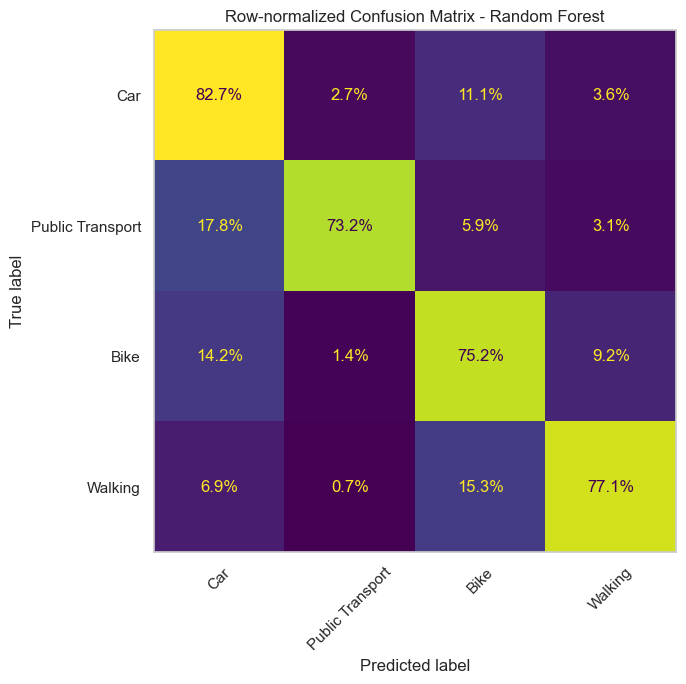


 XGBoost
                  precision    recall  f1-score   support

             Car     0.8425    0.8629    0.8526     11755
Public Transport     0.8004    0.6838    0.7376      1572
            Bike     0.7390    0.7791    0.7585      7632
         Walking     0.8182    0.7408    0.7776      4962

        accuracy                         0.8040     25921
       macro avg     0.8000    0.7667    0.7816     25921
    weighted avg     0.8048    0.8040    0.8035     25921

Train accuracy: 0.8228 | Test accuracy: 0.8040 | Gap: 0.0188


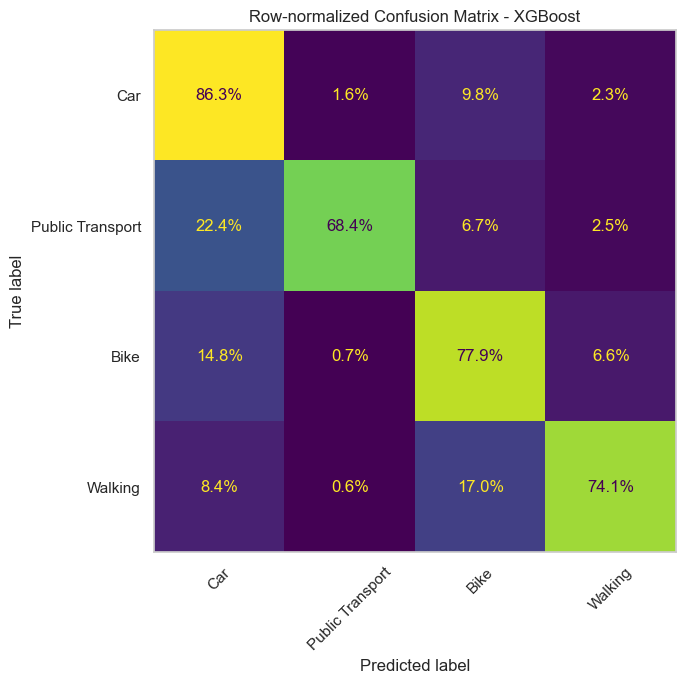

In [28]:
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

best_rf.fit(X, y_train)
best_xgb.fit(X, y_train)

final_reports = {}

for name, model in {'Random Forest': best_rf, 'XGBoost': best_xgb}.items():
    y_pred = model.predict(X_test_selected)

    print(f'\n {name}')
    report = classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    final_reports[name] = report
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0,
        digits=4,
    ))

    y_train_pred = model.predict(X)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = report['accuracy']
    print(f'Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f} | Gap: {train_acc - test_acc:.4f}')

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, values_format='.1%')
    ax.set_title(f'Row-normalized Confusion Matrix - {name}')
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(f"images/confusion_matrix_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

# Model Evaluation

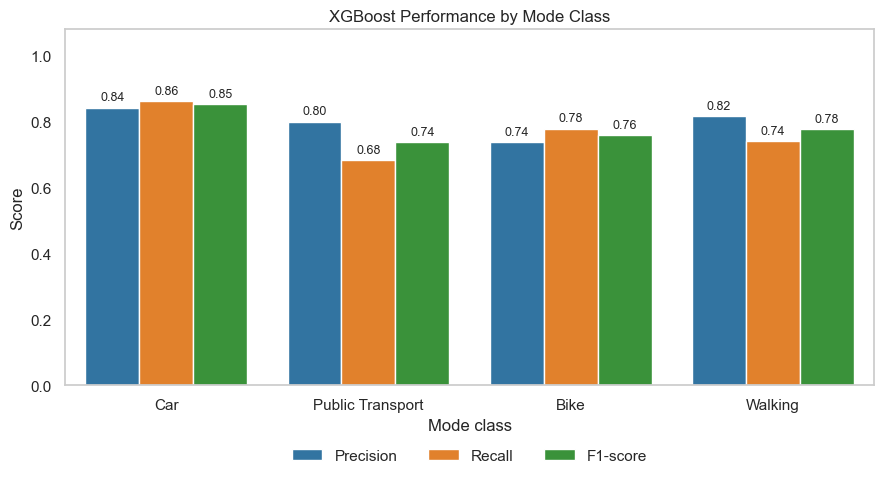

,Mode class,Precision,Recall,F1-score
0,Car,0.8425,0.8629,0.8526
1,Public Transport,0.8004,0.6838,0.7376
2,Bike,0.7390,0.7791,0.7585
3,Walking,0.8182,0.7408,0.7776


In [29]:
# Plot precision, recall, and F1-score per mode class for the final XGBoost model
xgb_report = final_reports["XGBoost"]

metrics_df = (
    pd.DataFrame(xgb_report)
    .T
    .loc[label_names, ["precision", "recall", "f1-score"]]
    .reset_index()
    .rename(columns={
        "index": "Mode class",
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-score",
    })
)

metrics_long = metrics_df.melt(
    id_vars="Mode class",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=metrics_long,
    x="Mode class",
    y="Score",
    hue="Metric",
    palette=sns.color_palette("tab10", 3)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.title("XGBoost Performance by Mode Class")
plt.xlabel("Mode class")
plt.ylabel("Score")
plt.ylim(0, 1.08)
plt.grid(False)
plt.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=3,
    frameon=False
)
plt.tight_layout()
plt.savefig("images/xgboost_class_metrics.png", dpi=150)
plt.show()

metrics_df.round(4)

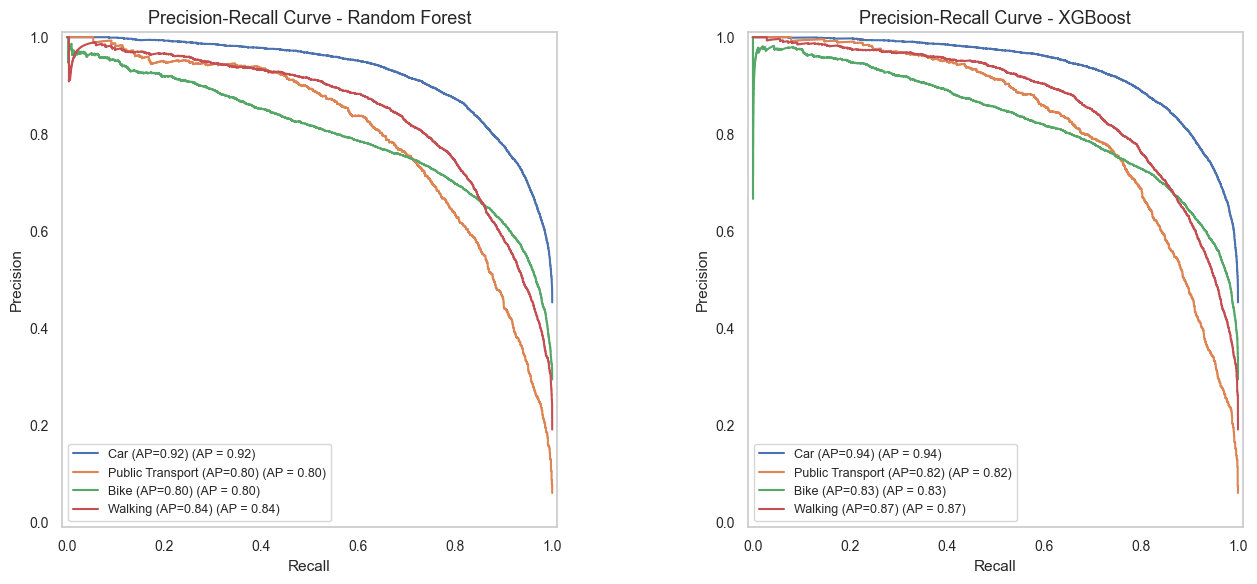

In [30]:
# Precision Recall plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model) in zip(axes, {'Random Forest': best_rf, 'XGBoost': best_xgb}.items()):
    y_score = model.predict_proba(X_test_selected)
    for i, label in enumerate(label_names):
        y_bin = (y_test == i).astype(int)
        ap = average_precision_score(y_bin, y_score[:, i])
        PrecisionRecallDisplay.from_predictions(
            y_bin,
            y_score[:, i],
            name=f'{label} (AP={ap:.2f})',
            ax=ax,
        )
    ax.set_title(f'Precision-Recall Curve - {name}', fontsize=13)
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(False)
    ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('images/precision_recall_curves.png', dpi=150)
plt.show()

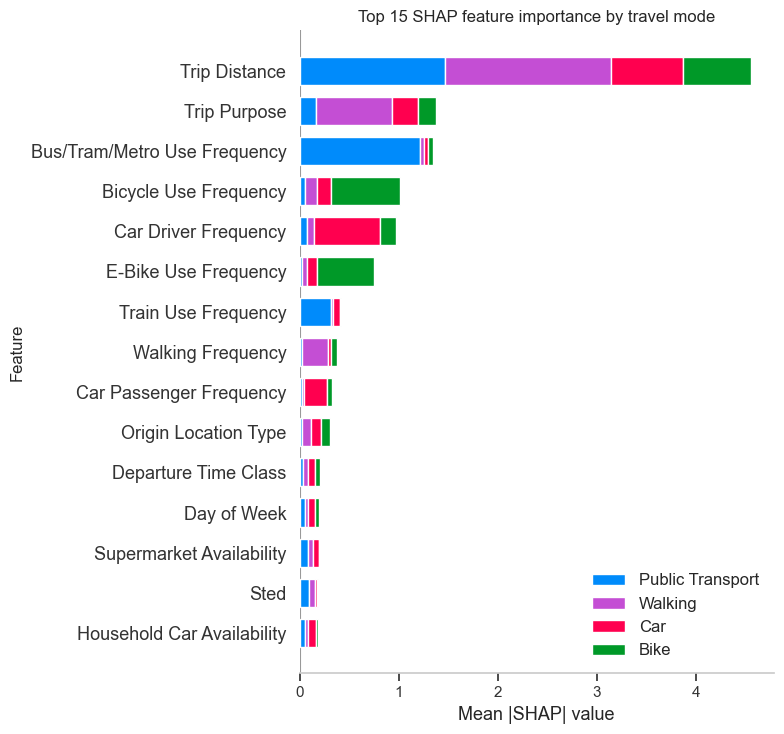

In [31]:
best_final = best_xgb
X_shap = X_test_selected.sample(n=min(3000, len(X_test_selected)), random_state=42)

explainer = shap.TreeExplainer(best_final.named_steps['classifier'])
shap_vals = explainer.shap_values(X_shap)

# Summary bar: mean SHAP across all classes.
fig, ax = plt.subplots(figsize=(10, 7))
readable_feature_names = [
    feature_labels.get(col, col)
    for col in X_shap.columns
]

shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=readable_feature_names,
    class_names=label_names,
    plot_type='bar',
    max_display=15,
    show=False,
)

plt.gca().set_title('Top 15 SHAP feature importance by travel mode')
plt.gca().set_xlabel('Mean |SHAP| value')
plt.gca().set_ylabel('Feature')
plt.grid(False)
plt.tight_layout()
plt.savefig('images/shap_summary_bar_top15.png', dpi=150, bbox_inches='tight')
plt.show()


# Export For Topic 3

In [32]:
import joblib
from pathlib import Path

output_dir = Path('./outputs')
output_dir.mkdir(parents=True, exist_ok=True)

model_path = output_dir / 'xgb_mode_choice_pipeline.pkl'
metadata_path = output_dir / 'mode_choice_metadata.json'
evaluation_path = output_dir / 'mode_choice_evaluation.json'

joblib.dump(best_final, model_path)

metadata = {
    'model_type': 'XGBoost_mode_pred',
    'source_notebook': 'Topic2_ModePrediction.ipynb',
    'target': 'KHvm_recoded_4class',
    'target_classes': class_labels,
    'feature_columns': selected_features,
    'scenario_features': scenario_features,
    'origin_linkage': 'VertPC_PRAM -> PC4 -> PC4-level Topic 1 amenity proportions',
    'notes': [
        'Only regular trips are used: Verpl == 1.',
        'Tree-based models are used without preprocessing or scaling.',
        'Metrics are evaluated on observed ODiN trips, without FactorV weighting.',
        'Fq and Brb variables are included as habit/perceived-access controls, not direct what-if policy levers.',
    ],
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

xgb_pred = best_final.predict(X_test_selected)
xgb_cm = confusion_matrix(y_test, xgb_pred, normalize='true')

with evaluation_path.open('w', encoding='utf-8') as f:
    json.dump({
        'n_rows': int(len(X_full)),
        'n_train': int(len(X_train)),
        'n_test': int(len(X_test_selected)),
        'classification_report': final_reports['XGBoost'],
        'confusion_matrix_row_normalized': xgb_cm.round(4).tolist(),
    }, f, indent=2)

print('Saved model:', model_path)
print('Saved metadata:', metadata_path)
print('Saved evaluation:', evaluation_path)

Saved model: outputs/xgb_mode_choice_pipeline.pkl
Saved metadata: outputs/mode_choice_metadata.json
Saved evaluation: outputs/mode_choice_evaluation.json
